# KNN Regressor with `make_regression` Dataset

## Simple English: What is KNN Regressor?
- **KNN** means **K-Nearest Neighbors**.
- For a new data point, KNN finds the `k` most similar points from training data.
- In **regression**, the prediction is usually the average of those neighbors' target values.

In simple English: KNN predicts by looking at nearby examples and taking their average answer.

### Why scaling is important for KNN
KNN uses distance. If one feature has bigger numeric range, it can dominate distance.
So we use **StandardScaler** before KNN.

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Create Synthetic Regression Dataset

In [ ]:
X, y = make_regression(
    n_samples=1000,
    n_features=7,
    noise=5,
    random_state=42
)

feature_names = [f'feature_{i+1}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='target')

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)
display(X.head())
print('\nTarget sample values:')
print(y.head())

Shape of X: (1000, 7)
Shape of y: (1000,)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7
0,0.058984,-0.342549,0.446873,-0.658248,0.170464,-0.982294,0.453509
1,-0.847634,-1.089633,-0.652089,0.397927,-0.784762,-0.218046,1.809306
2,-0.898468,-0.009119,0.028181,-0.174960,1.085896,0.536510,-0.755745
3,-0.214955,0.702660,0.385750,-0.719990,0.240877,-1.253506,-0.924063
4,-0.552921,-0.497571,1.001825,-0.975366,-0.782003,0.664703,1.303508



Target sample values:
0    -49.846093
1   -160.646832
2     -5.754327
3      9.714959
4    -61.940319
Name: target, dtype: float64


## Step 3: Quick Data Check

In [3]:
print('Missing values per column:')
print(X.isnull().sum())

print('\nTarget summary:')
print(y.describe())

Missing values per column:
feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
feature_6    0
feature_7    0
dtype: int64

Target summary:
count    1000.000000
mean        2.495652
std       119.176708
min      -401.114393
25%       -75.488718
50%         1.573918
75%        82.297440
max       385.107669
Name: target, dtype: float64


## Step 4: Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 800
Testing samples: 200


## Step 5: Build KNN Pipeline
We use StandardScaler + KNeighborsRegressor.

In [14]:
knn_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=7, weights='distance', p=2))
])

## Step 6: Train and Predict

In [12]:
knn_pipeline.fit(X_train, y_train)
y_pred = knn_pipeline.predict(X_test)

print('First 5 predictions:', y_pred[:5])

First 5 predictions: [ 70.61757803 -22.49331714  70.46135673 -41.7389672  107.84938587]


## Step 7: Important Scores
- MAE: average absolute error (lower is better)
- RMSE: penalizes large errors more (lower is better)
- R2: explained variance score (closer to 1 is better)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

scores_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [mae, rmse, r2]
})

display(scores_df)
print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R2:   {r2:.4f}')

,Metric,Value
0,MAE,34.380606
1,RMSE,46.388244
2,R2,0.846994


MAE:  34.381
RMSE: 46.388
R2:   0.8470


## Step 8: Graphs for Model Performance

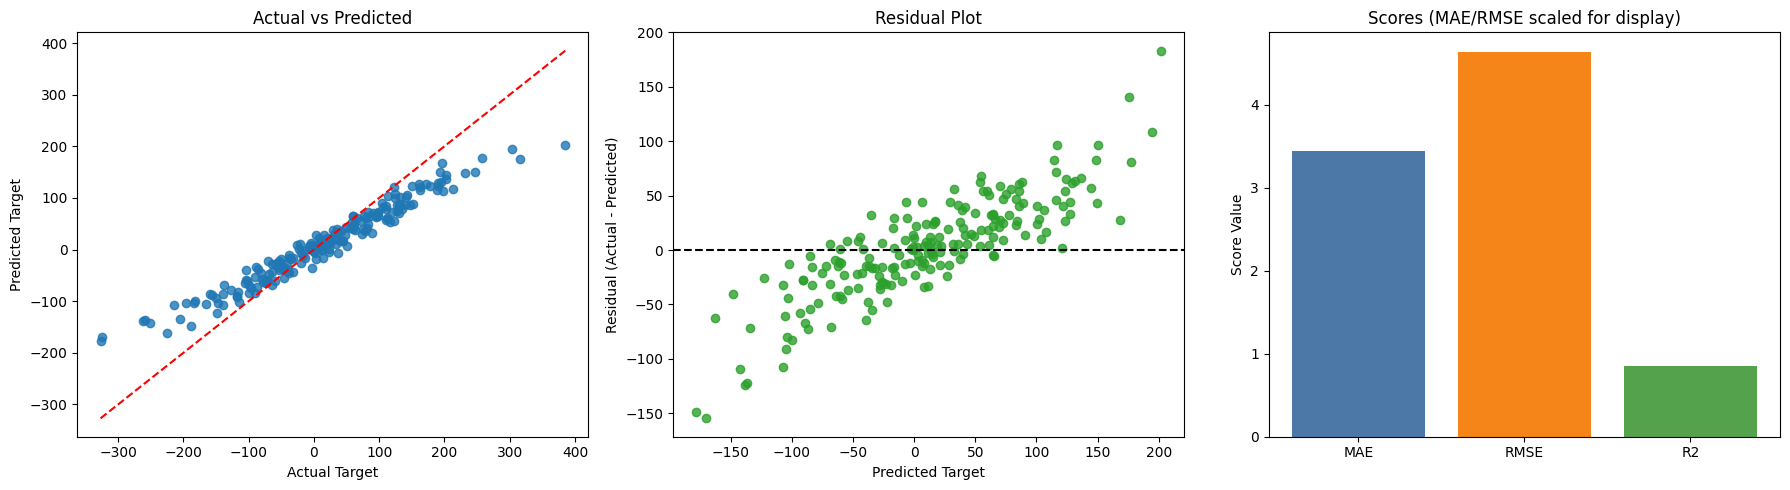

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='tab:blue', alpha=0.8)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Target')
axes[0].set_ylabel('Predicted Target')

# 2) Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='tab:green', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Target')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# 3) Scores bar chart
plot_scores = scores_df.copy()
mae_rmse_mask = plot_scores['Metric'].isin(['MAE', 'RMSE'])
plot_scores.loc[mae_rmse_mask, 'Value'] = plot_scores.loc[mae_rmse_mask, 'Value'] / 10
axes[2].bar(plot_scores['Metric'], plot_scores['Value'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[2].set_title('Scores (MAE/RMSE scaled for display)')
axes[2].set_ylabel('Score Value')

plt.tight_layout()
plt.show()

## Step 9: Compare Actual vs Predicted Values

In [16]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
comparison_df['Absolute_Error'] = (comparison_df['Actual'] - comparison_df['Predicted']).abs()
display(comparison_df.head(10))

,Actual,Predicted,Absolute_Error
0,98.274232,70.617578,27.656654
1,-70.674538,-22.493317,48.181221
2,129.634951,70.461357,59.173594
3,-40.469741,-41.738967,1.269226
4,124.672345,107.849386,16.822960
5,-59.328370,-27.534549,31.793821
6,110.753171,56.686609,54.066563
7,10.831268,-0.174710,11.005977
8,55.294202,41.687897,13.606305
9,31.707986,32.541442,0.833455


## Step 10: Optional K Value Comparison
Try different `k` values and compare R2 score.

,k,R2
0,1,0.746162
1,3,0.857027
2,5,0.855682
3,7,0.870068
4,9,0.867560
5,11,0.863969
6,15,0.856966


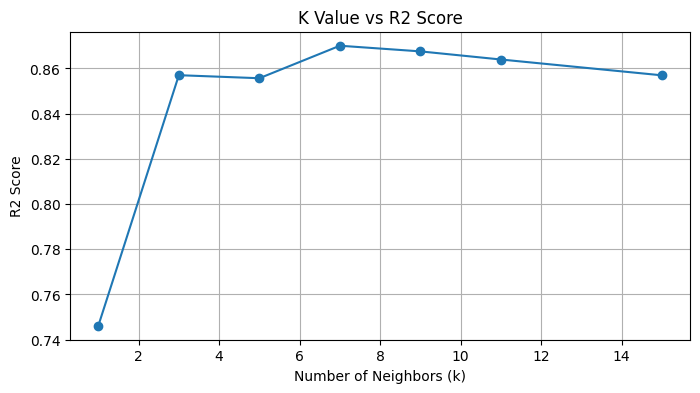

In [17]:
k_values = [1, 3, 5, 7, 9, 11, 15]
r2_scores = []

for k in k_values:
    model = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k, weights='distance'))
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2_scores.append(r2_score(y_test, preds))

k_result_df = pd.DataFrame({'k': k_values, 'R2': r2_scores})
display(k_result_df)

plt.figure(figsize=(8, 4))
plt.plot(k_values, r2_scores, marker='o')
plt.title('K Value vs R2 Score')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R2 Score')
plt.grid(True)
plt.show()

## Simple English Summary
- KNN Regressor predicts by averaging nearby training points.
- Scaling is important because KNN is distance-based.
- MAE, RMSE, and R2 tell us prediction quality.
- Graphs show closeness of predictions and error pattern.
- You can tune `k` to improve performance.